This code is for generating a benchmarking SV callset for HapMap Mix with supporting reads.
The germline SVs in HPRC cell lines are supposed to be mosaic variants in HapMap Mix.
The goal is to locate the "True" mosaic SVs in the HapMap mix where we can find the same signal in HPRC cell lines. If this is the case, we can further benchmark our methylation analysis with the supporting reads in HapMap Mix and HRPC cell lines. 


HapMap Mix:
| Sample | HG00438 | HG002 | HG02257 | HG02486 | HG02622 | HG005 |
|--------|-------------|-------------|-------------|-------------|-------------|-------------|
| Proportion | .5% | 2% | 2% | 2% | 10% | 83.5% |

Input:
- Assembly-polished SVs of 6 HPRC celllines.
- 6 individual Sniffles called HPRC celllines.
  - with supporting reads.


In [1]:
import pandas as pd
import pysam
from src.vcf_to_df import read_vcf_to_df_comp
from src.vcf_to_df import read_vcf_to_df    
from tqdm import tqdm
import seaborn as sns
import matplotlib.pyplot as plt
hprc_sample_list = ["HG002", "HG00438", "HG005", "HG02257", "HG02486", "HG02622"]

In [ ]:
assembly_based_sv = pysam.VariantFile("./dataset/assembly_based_sv.vcf.gz")
# assembly_based_sv_df = read_vcf_to_df_comp(assembly_based_sv)
for i in hprc_sample_list:
    sample_based_sv = read_vcf_to_df(pysam.VariantFile(f"./dataset/sniffles_call/{i}.sorted_germline.vcf.gz"))


In [ ]:
# uncomment for re-producing the sv_df

# sv_df = pd.DataFrame(columns=["chr", "location", "id", "sv_len"] + hprc_sample_list)
# for record in tqdm(assembly_based_sv.fetch(), desc="Processing records"):
#     df_record = {"chr": record.chrom, "location": record.pos, "id": record.id, "sv_len": record.info["SVLEN"]}
#     for sample_name in hprc_sample_list:
#         df_record.update({sample_name: record.samples[sample_name]['GT']})
#     sv_df.loc[len(sv_df)] = df_record
# sv_df.to_csv(f"./dataset/assembly_based_sv_df.csv", index=False)


Processing records: 106509it [20:27, 86.78it/s]


In [7]:
sv_df = pd.read_csv(f"./dataset/assembly_based_sv_df.csv")

In [8]:
def is_only_one_not_zero_zero(row, sample_list = hprc_sample_list):
    non_zero_count = sum((row[sample] != "(0, 0)")  for sample in sample_list)
    return non_zero_count == 1
sv_only_in_one_sample = sv_df[sv_df.apply(is_only_one_not_zero_zero, axis=1)]
sv_only_in_one_sample

,chr,location,id,sv_len,HG002,HG00438,HG005,HG02257,HG02486,HG02622
1,chr1,710579,HapMapBench.00000002,344,"(0, 0)","(1, 0)","(0, 0)","(0, 0)","(0, 0)","(0, 0)"
2,chr1,710579,HapMapBench.00000003,336,"(0, 0)","(0, 0)","(0, 0)","(1, 0)","(0, 0)","(0, 0)"
3,chr1,710579,HapMapBench.00000004,320,"(0, 0)","(0, 0)","(0, 0)","(0, 1)","(0, 0)","(0, 0)"
4,chr1,710579,HapMapBench.00000005,319,"(0, 0)","(0, 0)","(0, 0)","(0, 0)","(0, 0)","(1, 0)"
5,chr1,711958,HapMapBench.00000006,-90,"(0, 0)","(0, 0)","(0, 0)","(0, 0)","(0, 0)","(0, 1)"
...,...,...,...,...,...,...,...,...,...,...
106501,chr22,50748509,HapMapBench.00106502,151,"(1, 0)","(0, 0)","(0, 0)","(0, 0)","(0, 0)","(0, 0)"
106503,chr22,50748814,HapMapBench.00106504,203,"(0, 0)","(0, 0)","(0, 0)","(1, 0)","(0, 0)","(0, 0)"
106505,chr22,50748963,HapMapBench.00106506,50,"(0, 0)","(0, 0)","(0, 0)","(1, 0)","(0, 0)","(0, 0)"
106506,chr22,50759786,HapMapBench.00106507,51,"(0, 0)","(0, 0)","(0, 0)","(1, 0)","(0, 0)","(0, 0)"


In [9]:
location_diff = sv_only_in_one_sample['location'].diff().abs()
# Filter out distinct structural variants (SVs) from a DataFrame
distinct_sv_df = sv_only_in_one_sample[(location_diff > 1000) | (location_diff.isna())]
distinct_sv_df

,chr,location,id,sv_len,HG002,HG00438,HG005,HG02257,HG02486,HG02622
1,chr1,710579,HapMapBench.00000002,344,"(0, 0)","(1, 0)","(0, 0)","(0, 0)","(0, 0)","(0, 0)"
5,chr1,711958,HapMapBench.00000006,-90,"(0, 0)","(0, 0)","(0, 0)","(0, 0)","(0, 0)","(0, 1)"
7,chr1,714355,HapMapBench.00000008,-97,"(0, 0)","(0, 0)","(0, 0)","(0, 0)","(0, 0)","(1, 0)"
8,chr1,724994,HapMapBench.00000009,-2184,"(0, 0)","(0, 0)","(0, 0)","(0, 0)","(0, 0)","(0, 1)"
9,chr1,727299,HapMapBench.00000010,97,"(0, 0)","(0, 0)","(0, 0)","(0, 0)","(0, 0)","(0, 1)"
...,...,...,...,...,...,...,...,...,...,...
106495,chr22,50697556,HapMapBench.00106496,302,"(0, 0)","(0, 0)","(0, 0)","(0, 0)","(0, 0)","(1, 0)"
106496,chr22,50715763,HapMapBench.00106497,98,"(0, 0)","(0, 0)","(0, 0)","(0, 1)","(0, 0)","(0, 0)"
106499,chr22,50748482,HapMapBench.00106500,125,"(0, 0)","(0, 1)","(0, 0)","(0, 0)","(0, 0)","(0, 0)"
106506,chr22,50759786,HapMapBench.00106507,51,"(0, 0)","(0, 0)","(0, 0)","(1, 0)","(0, 0)","(0, 0)"


In [10]:
with open("./dataset/distinct_sv.list", "w") as f:
    for index, row in distinct_sv_df.iterrows():
        f.write(f"{row.id}\n")

In [ ]:
# uncomment to get all the distinct SVs.
# !bcftools view -Oz -o ./dataset/assembly_based_sv_distinct_heterozygous.vcf.gz -i 'ID=@/stornext/snfs4/next-gen/scratch/Yilei/projects/sv_methylation/SniffMeth/dataset/distinct_sv.list' ./dataset/assembly_based_sv.vcf.gz
# !tabix -p vcf ./dataset/assembly_based_sv_distinct_heterozygous.vcf.gz

In [ ]:
# uncomment and paste to the terminal to get the benchmarking results
# truvari bench -b ./dataset/assembly_based_sv_distinct_heterozygous.vcf.gz -c ./dataset/sniffles_call/HG002.sorted_germline.vcf.gz -o ./dataset/assembly_based_sv_distinct_heterozygous_bench_HG002  --pctseq 0.9 --pctsize 0.9 --passonly 
# truvari bench -b ./dataset/assembly_based_sv_distinct_heterozygous.vcf.gz -c ./dataset/sniffles_call/HG00438.sorted_germline.vcf.gz -o ./dataset/assembly_based_sv_distinct_heterozygous_bench_HG00438  --pctseq 0.9 --pctsize 0.9 --passonly
# truvari bench -b ./dataset/assembly_based_sv_distinct_heterozygous.vcf.gz -c ./dataset/sniffles_call/HG005.sorted_germline.vcf.gz -o ./dataset/assembly_based_sv_distinct_heterozygous_bench_HG005  --pctseq 0.9 --pctsize 0.9 --passonly
# truvari bench -b ./dataset/assembly_based_sv_distinct_heterozygous.vcf.gz -c ./dataset/sniffles_call/HG02257.sorted_germline.vcf.gz -o ./dataset/assembly_based_sv_distinct_heterozygous_bench_HG02257  --pctseq 0.9 --pctsize 0.9 --passonly
# truvari bench -b ./dataset/assembly_based_sv_distinct_heterozygous.vcf.gz -c ./dataset/sniffles_call/HG02486.sorted_germline.vcf.gz -o ./dataset/assembly_based_sv_distinct_heterozygous_bench_HG02486  --pctseq 0.9 --pctsize 0.9 --passonly
# truvari bench -b ./dataset/assembly_based_sv_distinct_heterozygous.vcf.gz -c ./dataset/sniffles_call/HG02622.sorted_germline.vcf.gz -o ./dataset/assembly_based_sv_distinct_heterozygous_bench_HG02622  --pctseq 0.9 --pctsize 0.9 --passonly

In [11]:
hprc_sv_matched_df_list = []
for hprc_sample in hprc_sample_list:
    hprc_sv_df = read_vcf_to_df(pysam.VariantFile(f"dataset/hprc_truvari/assembly_based_sv_distinct_heterozygous_bench_{hprc_sample}/tp-comp.vcf.gz"))
    hprc_assembly_sv_df = read_vcf_to_df_comp(pysam.VariantFile(f"dataset/hprc_truvari/assembly_based_sv_distinct_heterozygous_bench_{hprc_sample}/tp-base.vcf.gz"))
    hprc_sv_df_matched = pd.concat([hprc_sv_df, hprc_assembly_sv_df.add_suffix("_asm")], axis=1)
    hprc_sv_df_matched_same_sample = hprc_sv_df_matched[hprc_sv_df_matched["sample_name_asm"] == hprc_sample]
    hprc_sv_matched_df_list.append(hprc_sv_df_matched_same_sample)


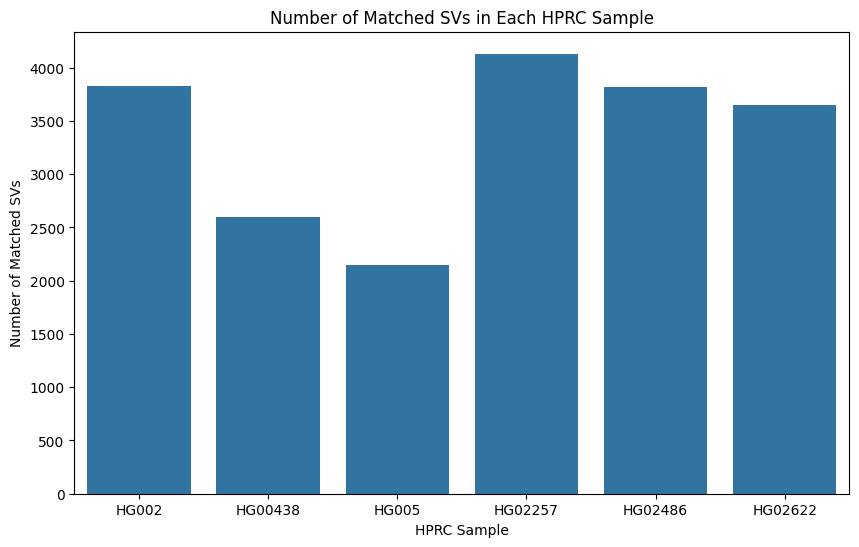

In [12]:
# Count the number of matched SVs in each HPRC sample
matched_sv_counts = [len(df) for df in hprc_sv_matched_df_list]
sample_names = hprc_sample_list
# Create a bar chart
plt.figure(figsize=(10, 6))
sns.barplot(x=sample_names, y=matched_sv_counts)
plt.xlabel('HPRC Sample')
plt.ylabel('Number of Matched SVs')
plt.title('Number of Matched SVs in Each HPRC Sample')
plt.show()

In [56]:
# uncomment to get the benchmarking results
# truvari bench -b ./dataset/assembly_based_sv_distinct_heterozygous.vcf.gz -c ./dataset/hapmap_smaht_ont_mosaic.vcf.gz -o ./dataset/assembly_based_sv_distinct_heterozygous_bench_hapmap  --pctseq 0.9 --pctsize 0.9 --passonly

In [13]:
hprc_sv_matched_df_total = pd.concat(hprc_sv_matched_df_list, axis=0).reset_index(drop=True)
final_matched_hprc_sv_df = hprc_sv_matched_df_total[(abs(hprc_sv_matched_df_total['sv_len']) > 100) & (hprc_sv_matched_df_total['stdev_len'] < 10) & (hprc_sv_matched_df_total['stdev_pos'] < 10)].sort_values("id_asm")

In [14]:
hapmap_hetero_confirmed_sv = "dataset/assembly_based_sv_distinct_heterozygous_bench_hapmap/tp-comp.vcf.gz"
hapmap_hetero_confirmed_sv_df = read_vcf_to_df(pysam.VariantFile(hapmap_hetero_confirmed_sv))
hprc_hapmap_hetero_confirmed_sv = "dataset/assembly_based_sv_distinct_heterozygous_bench_hapmap/tp-base.vcf.gz"
hprc_hapmap_hetero_confirmed_sv_df = read_vcf_to_df_comp(pysam.VariantFile(hprc_hapmap_hetero_confirmed_sv))
hetro_hapmap_benchmark_list = pd.concat([hapmap_hetero_confirmed_sv_df, hprc_hapmap_hetero_confirmed_sv_df.add_suffix("_asm")], axis=1)

In [21]:
len(hetro_hapmap_benchmark_list)

6013

In [16]:
hetro_hapmap_benchmark_list.to_csv("./dataset/hetro_hapmap_benchmark_list.csv", index=False)

In [18]:
all_final_checks_df = pd.merge(hetro_hapmap_benchmark_list, final_matched_hprc_sv_df, suffixes=('_hapmap', '_hprc'), on='id_asm')
all_final_checks_df.to_csv("./dataset/all_final_checks_df.csv", index=False)

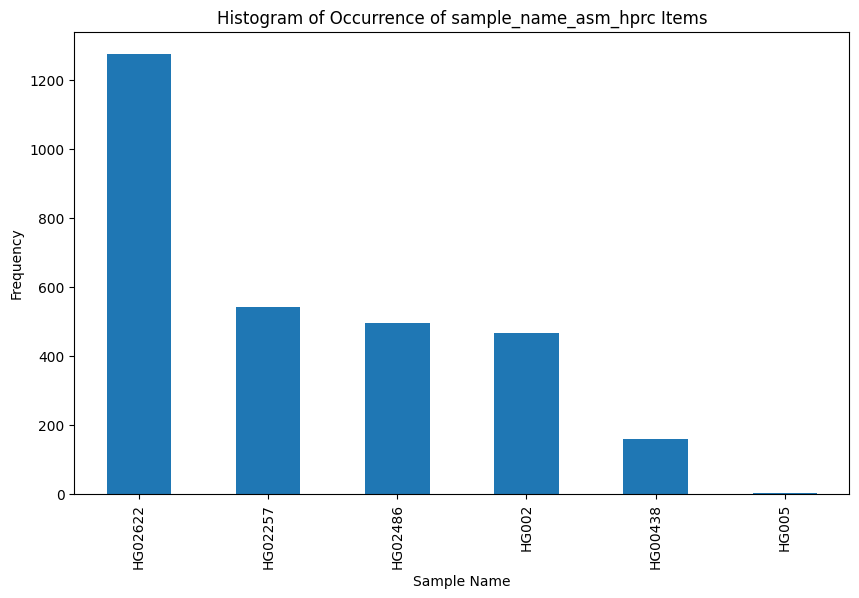

In [19]:
plt.figure(figsize=(10, 6))
all_final_checks_df['sample_name_asm_hprc'].value_counts().plot(kind='bar')
plt.xlabel('Sample Name')
plt.ylabel('Frequency')
plt.title('Histogram of Occurrence of sample_name_asm_hprc Items')
plt.show()

In [8]:
all_final_checks_df = pd.read_csv("./dataset/all_final_checks_df.csv")

In [4]:
all_final_checks_df

,chr_hapmap,location_hapmap,id_hapmap,sv_len_hapmap,supporting_reads_hapmap,stdev_len_hapmap,stdev_pos_hapmap,ref_start_hapmap,ref_end_hapmap,chr_asm_hapmap,...,sv_len_hprc,supporting_reads_hprc,stdev_len_hprc,stdev_pos_hprc,ref_start_hprc,ref_end_hprc,chr_asm_hprc,location_asm_hprc,sv_len_asm_hprc,sample_name_asm_hprc
0,chr1,868472,Sniffles2.INS.4BS0,2523,"('3dfef383-e3cb-4a92-be93-92a3aec61064', '3c24...",1.414,0.707,868471,868474,chr1,...,2534,"('94ea974f-3ed7-4606-834c-2ab31f346d28', '7bf6...",4.886,0.459,868469,868475,chr1,868470,2559,HG00438
1,chr1,1175869,Sniffles2.INS.78S0,272,"('0b25d640-93a7-4391-810d-deae99c50f83', '9d19...",0.000,0.000,1175869,1175869,chr1,...,269,"('2d5eeb25-3e05-408c-859b-654abd581e11', '720c...",1.982,0.000,1175868,1175869,chr1,1175868,272,HG02622
2,chr1,1508184,Sniffles2.DEL.2223S0,-2201,"('0ac10069-db58-4d23-9873-385c683fe1bd', '20fe...",0.000,0.000,1508184,1510385,chr1,...,-2201,"('84ab352d-dc03-4c1d-987b-91c8d231fdbf', 'ac57...",0.000,0.000,1508183,1510384,chr1,1508183,-2201,HG02622
3,chr1,1934280,Sniffles2.INS.B5S0,102,"('d3d2fa97-a3a0-4417-be97-b164003ccc52', 'e9aa...",0.000,0.000,1934280,1934280,chr1,...,102,"('7741a12f-f237-405c-9f2b-a947ced7f680', 'e41f...",1.055,1.732,1934277,1934281,chr1,1934279,102,HG02257
4,chr1,2997725,Sniffles2.INS.167S0,494,"('588544e7-ca85-4f69-8bad-b10b75fc7e54', '201f...",2.000,0.000,2997725,2997727,chr1,...,492,"('c9669816-d1dc-49fe-be93-68bfb53d14fa', '8c25...",3.742,6.255,2997717,2997733,chr1,2997724,494,HG02622
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2935,chr22,47043976,Sniffles2.INS.7C8S15,126,"('82a70431-f466-4940-a404-fc4f6fdcdc45', 'ecbf...",1.291,0.000,47043976,47043977,chr22,...,128,"('b3444cb5-e0c3-4f3c-a43f-b49196b7da10', 'fd24...",0.799,3.075,47043971,47043978,chr22,47043975,128,HG02622
2936,chr22,48905001,Sniffles2.DEL.1845S15,-130,"('b693ed8c-4d98-4e0c-b251-da06e8bfd081', '713b...",0.000,0.000,48905001,48905131,chr22,...,-130,"('d5f32e7c-d583-4992-862f-1bfafb90d37d', 'e20c...",0.497,7.415,48904992,48905137,chr22,48905000,-130,HG002
2937,chr22,48959671,Sniffles2.DEL.1854S15,-103,"('391ff706-cd00-4203-8119-97aa06091979', '5458...",0.000,4.041,48959666,48959778,chr22,...,-103,"('74369b35-12d9-4cc4-a4a3-4476798daeb2', '44dd...",0.702,4.227,48959658,48959770,chr22,48959663,-103,HG02622
2938,chr22,49917987,Sniffles2.INS.8A1S15,171,"('a1267735-77f6-49e8-8a9f-af26d116ec44', '0718...",0.837,0.000,49917987,49917987,chr22,...,190,"('6ccecc3a-6029-4bdf-bda3-05eb58c6b3f8', '715d...",2.060,0.000,49917986,49917988,chr22,49917986,190,HG00438


In [6]:
# check if corresponding SVs' supporting reads have the same methylation profile. 
# So I need to get the methylation in supporting reads from HPRC samples 

with open("dataset/hapmap_benchmark/hapmap_benchmark_sv.list", "w") as hapmap_filtered_sv_f:
    for i in all_final_checks_df.id_hapmap:
        hapmap_filtered_sv_f.writelines(f"{i}\n")
        
for hprc_sample in hprc_sample_list:
    current_hprc_sample_match = all_final_checks_df[all_final_checks_df.sample_name_asm_hprc == hprc_sample]
    with open(f"dataset/hapmap_benchmark/{hprc_sample}_benchmark_sv.list", "w") as hprc_filtered_sv_f:
        for i in current_hprc_sample_match.id_hprc:
            hprc_filtered_sv_f.writelines(f"{i}\n")

In [9]:
!bcftools view -i ID=@./dataset/hapmap_benchmark/hapmap_benchmark_sv.list ./dataset/assembly_based_sv_distinct_heterozygous_bench_hapmap/tp-comp.vcf.gz > ./dataset/hapmap_benchmark/hapmap_benchmark_sv.vcf
!bcftools view -i ID=@./dataset/hapmap_benchmark/HG002_benchmark_sv.list ./dataset/hprc_truvari/assembly_based_sv_distinct_heterozygous_bench_HG002/tp-comp.vcf.gz > ./dataset/hapmap_benchmark/HG002_benchmark_sv.vcf
!bcftools view -i ID=@./dataset/hapmap_benchmark/HG00438_benchmark_sv.list ./dataset/hprc_truvari/assembly_based_sv_distinct_heterozygous_bench_HG00438/tp-comp.vcf.gz > ./dataset/hapmap_benchmark/HG00438_benchmark_sv.vcf
!bcftools view -i ID=@./dataset/hapmap_benchmark/HG005_benchmark_sv.list ./dataset/hprc_truvari/assembly_based_sv_distinct_heterozygous_bench_HG005/tp-comp.vcf.gz > ./dataset/hapmap_benchmark/HG005_benchmark_sv.vcf
!bcftools view -i ID=@./dataset/hapmap_benchmark/HG02257_benchmark_sv.list ./dataset/hprc_truvari/assembly_based_sv_distinct_heterozygous_bench_HG02257/tp-comp.vcf.gz > ./dataset/hapmap_benchmark/HG02257_benchmark_sv.vcf
!bcftools view -i ID=@./dataset/hapmap_benchmark/HG02486_benchmark_sv.list ./dataset/hprc_truvari/assembly_based_sv_distinct_heterozygous_bench_HG02486/tp-comp.vcf.gz > ./dataset/hapmap_benchmark/HG02486_benchmark_sv.vcf
!bcftools view -i ID=@./dataset/hapmap_benchmark/HG02622_benchmark_sv.list ./dataset/hprc_truvari/assembly_based_sv_distinct_heterozygous_bench_HG02622/tp-comp.vcf.gz > ./dataset/hapmap_benchmark/HG02622_benchmark_sv.vcf

In [ ]:
# ./sniffmeth  -v ./dataset/hapmap_benchmark/benchmark_sv_vcf/hapmap_benchmark_sv.vcf -b ../hapmap_data/hapmap_smaht_ont.bam -r ../../../references/GCA_000001405.15_GRCh38_no_alt_analysis_set.fa  -o ./dataset/hapmap_benchmark/no_smoothing/ttest/hapmap -m 3 -t 8 
# ./sniffmeth  -v ./dataset/hapmap_benchmark/benchmark_sv_vcf/HG002_benchmark_sv.vcf -b ../hprc_data/HG002.sorted.bam -b2 ../hapmap_data/hapmap_smaht_ont.bam  -r ../../../references/GCA_000001405.15_GRCh38_no_alt_analysis_set.fa  -o ./dataset/hapmap_benchmark/no_smoothing/ttest/HG002 -m 3 -t 20
# ./sniffmeth -v ./dataset/hapmap_benchmark/benchmark_sv_vcf/HG00438_benchmark_sv.vcf -b ../hprc_data/HG00438.sorted.bam -b2 ../hapmap_data/hapmap_smaht_ont.bam  -r ../../../references/GCA_000001405.15_GRCh38_no_alt_analysis_set.fa  -o ./dataset/hapmap_benchmark/no_smoothing/ttest/HG00438 -m 3 -t 20
# ./sniffmeth -v ./dataset/hapmap_benchmark/benchmark_sv_vcf/HG005_benchmark_sv.vcf -b ../hprc_data/HG005.sorted.bam -b2 ../hapmap_data/hapmap_smaht_ont.bam  -r ../../../references/GCA_000001405.15_GRCh38_no_alt_analysis_set.fa  -o ./dataset/hapmap_benchmark/no_smoothing/ttest/HG005 -m 3 -t 20
# ./sniffmeth -v ./dataset/hapmap_benchmark/benchmark_sv_vcf/HG02257_benchmark_sv.vcf -b ../hprc_data/HG02257.sorted.bam -b2 ../hapmap_data/hapmap_smaht_ont.bam  -r ../../../references/GCA_000001405.15_GRCh38_no_alt_analysis_set.fa  -o ./dataset/hapmap_benchmark/no_smoothing/ttest/HG02257 -m 3 -t 20
# ./sniffmeth -v ./dataset/hapmap_benchmark/benchmark_sv_vcf/HG02486_benchmark_sv.vcf -b ../hprc_data/HG02486.sorted.bam -b2 ../hapmap_data/hapmap_smaht_ont.bam  -r ../../../references/GCA_000001405.15_GRCh38_no_alt_analysis_set.fa  -o ./dataset/hapmap_benchmark/no_smoothing/ttest/HG02486 -m 3 -t 20
# ./sniffmeth -v ./dataset/hapmap_benchmark/benchmark_sv_vcf/HG02622_benchmark_sv.vcf -b ../hprc_data/HG02622.sorted.bam -b2 ../hapmap_data/hapmap_smaht_ont.bam  -r ../../../references/GCA_000001405.15_GRCh38_no_alt_analysis_set.fa  -o ./dataset/hapmap_benchmark/no_smoothing/ttest/HG02622 -m 3 -t 20


usage: SniffMeth [-h] -b BAM -v VCF -r REFERENCE -o OUTPUT [-t THREADS]
                 [-ob OUTPUT_BAM] [-s SMOOTHING] [-i INTERVAL]
                 [-m MIN_SUPPORTING] [-th THRESHHOLD] [-tf TEST_FUNCTION]
                 [-b2 SECOND_BAM]
SniffMeth: error: argument -i/--interval: invalid int value: './dataset/hapmap_benchmark/hapmap_benchmark_sv.vcf'


In [13]:
# ./sniffmeth  -v ./dataset/hapmap_benchmark/benchmark_sv_vcf/hapmap_benchmark_sv.vcf -b ../hapmap_data/hapmap_smaht_ont.bam -tf fisher -r ../../../references/GCA_000001405.15_GRCh38_no_alt_analysis_set.fa  -o ./dataset/hapmap_benchmark/no_smoothing/fisher/hapmap -m 3 -t 20
# ./sniffmeth  -v ./dataset/hapmap_benchmark/benchmark_sv_vcf/HG002_benchmark_sv.vcf -b ../hprc_data/HG002.sorted.bam -b2 ../hapmap_data/hapmap_smaht_ont.bam  -tf fisher -r ../../../references/GCA_000001405.15_GRCh38_no_alt_analysis_set.fa  -o ./dataset/hapmap_benchmark/no_smoothing/fisher/HG002 -m 3 -t 20
# ./sniffmeth -v ./dataset/hapmap_benchmark/benchmark_sv_vcf/HG00438_benchmark_sv.vcf -b ../hprc_data/HG00438.sorted.bam -b2 ../hapmap_data/hapmap_smaht_ont.bam  -tf fisher -r ../../../references/GCA_000001405.15_GRCh38_no_alt_analysis_set.fa  -o ./dataset/hapmap_benchmark/no_smoothing/fisher/HG00438 -m 3 -t 20
# ./sniffmeth -v ./dataset/hapmap_benchmark/benchmark_sv_vcf/HG005_benchmark_sv.vcf -b ../hprc_data/HG005.sorted.bam -b2 ../hapmap_data/hapmap_smaht_ont.bam  -tf fisher -r ../../../references/GCA_000001405.15_GRCh38_no_alt_analysis_set.fa  -o ./dataset/hapmap_benchmark/no_smoothing/fisher/HG005 -m 3 -t 20
# ./sniffmeth -v ./dataset/hapmap_benchmark/benchmark_sv_vcf/HG02257_benchmark_sv.vcf -b ../hprc_data/HG02257.sorted.bam -b2 ../hapmap_data/hapmap_smaht_ont.bam  -tf fisher -r ../../../references/GCA_000001405.15_GRCh38_no_alt_analysis_set.fa  -o ./dataset/hapmap_benchmark/no_smoothing/fisher/HG02257 -m 3 -t 20
# ./sniffmeth -v ./dataset/hapmap_benchmark/benchmark_sv_vcf/HG02486_benchmark_sv.vcf -b ../hprc_data/HG02486.sorted.bam -b2 ../hapmap_data/hapmap_smaht_ont.bam  -tf fisher -r ../../../references/GCA_000001405.15_GRCh38_no_alt_analysis_set.fa  -o ./dataset/hapmap_benchmark/no_smoothing/fisher/HG02486 -m 3 -t 20
# ./sniffmeth -v ./dataset/hapmap_benchmark/benchmark_sv_vcf/HG02622_benchmark_sv.vcf -b ../hprc_data/HG02622.sorted.bam -b2 ../hapmap_data/hapmap_smaht_ont.bam  -tf fisher -r ../../../references/GCA_000001405.15_GRCh38_no_alt_analysis_set.fa  -o ./dataset/hapmap_benchmark/no_smoothing/fisher/HG02622 -m 3 -t 20



The history saving thread hit an unexpected error (OperationalError('disk I/O error')).History will not be written to the database.


In [ ]:
# ./sniffmeth  -v ./dataset/hapmap_benchmark/benchmark_sv_vcf/hapmap_benchmark_sv.vcf -b ../hapmap_data/hapmap_smaht_ont.bam -tf fisher -r ../../../references/GCA_000001405.15_GRCh38_no_alt_analysis_set.fa -s 10 -o ./dataset/hapmap_benchmark/smoothing/fisher/hapmap -m 3 -t 20
# ./sniffmeth  -v ./dataset/hapmap_benchmark/benchmark_sv_vcf/HG002_benchmark_sv.vcf -b ../hprc_data/HG002.sorted.bam -b2 ../hapmap_data/hapmap_smaht_ont.bam  -tf fisher -r ../../../references/GCA_000001405.15_GRCh38_no_alt_analysis_set.fa -s 10 -o ./dataset/hapmap_benchmark/smoothing/fisher/HG002 -m 3 -t 20
# ./sniffmeth -v ./dataset/hapmap_benchmark/benchmark_sv_vcf/HG00438_benchmark_sv.vcf -b ../hprc_data/HG00438.sorted.bam -b2 ../hapmap_data/hapmap_smaht_ont.bam  -tf fisher -r ../../../references/GCA_000001405.15_GRCh38_no_alt_analysis_set.fa -s 10 -o ./dataset/hapmap_benchmark/smoothing/fisher/HG00438 -m 3 -t 20
# ./sniffmeth -v ./dataset/hapmap_benchmark/benchmark_sv_vcf/HG005_benchmark_sv.vcf -b ../hprc_data/HG005.sorted.bam -b2 ../hapmap_data/hapmap_smaht_ont.bam  -tf fisher -r ../../../references/GCA_000001405.15_GRCh38_no_alt_analysis_set.fa -s 10 -o ./dataset/hapmap_benchmark/smoothing/fisher/HG005 -m 3 -t 20
# ./sniffmeth -v ./dataset/hapmap_benchmark/benchmark_sv_vcf/HG02257_benchmark_sv.vcf -b ../hprc_data/HG02257.sorted.bam -b2 ../hapmap_data/hapmap_smaht_ont.bam  -tf fisher -r ../../../references/GCA_000001405.15_GRCh38_no_alt_analysis_set.fa -s 10 -o ./dataset/hapmap_benchmark/smoothing/fisher/HG02257 -m 3 -t 20
# ./sniffmeth -v ./dataset/hapmap_benchmark/benchmark_sv_vcf/HG02486_benchmark_sv.vcf -b ../hprc_data/HG02486.sorted.bam -b2 ../hapmap_data/hapmap_smaht_ont.bam  -tf fisher -r ../../../references/GCA_000001405.15_GRCh38_no_alt_analysis_set.fa -s 10 -o ./dataset/hapmap_benchmark/smoothing/fisher/HG02486 -m 3 -t 20
# ./sniffmeth -v ./dataset/hapmap_benchmark/benchmark_sv_vcf/HG02622_benchmark_sv.vcf -b ../hprc_data/HG02622.sorted.bam -b2 ../hapmap_data/hapmap_smaht_ont.bam  -tf fisher -r ../../../references/GCA_000001405.15_GRCh38_no_alt_analysis_set.fa -s 10 -o ./dataset/hapmap_benchmark/smoothing/fisher/HG02622 -m 3 -t 20

In [ ]:
# ./sniffmeth  -v ./dataset/hapmap_benchmark/benchmark_sv_vcf/hapmap_benchmark_sv.vcf -b ../hapmap_data/hapmap_smaht_ont.bam -r ../../../references/GCA_000001405.15_GRCh38_no_alt_analysis_set.fa -s 10 -o ./dataset/hapmap_benchmark/smoothing/ttest/hapmap -m 3 -t 20
# ./sniffmeth  -v ./dataset/hapmap_benchmark/benchmark_sv_vcf/HG002_benchmark_sv.vcf -b ../hprc_data/HG002.sorted.bam -b2 ../hapmap_data/hapmap_smaht_ont.bam  -r ../../../references/GCA_000001405.15_GRCh38_no_alt_analysis_set.fa -s 10 -o ./dataset/hapmap_benchmark/smoothing/ttest/HG002 -m 3 -t 20
# ./sniffmeth -v ./dataset/hapmap_benchmark/benchmark_sv_vcf/HG00438_benchmark_sv.vcf -b ../hprc_data/HG00438.sorted.bam -b2 ../hapmap_data/hapmap_smaht_ont.bam  -r ../../../references/GCA_000001405.15_GRCh38_no_alt_analysis_set.fa -s 10 -o ./dataset/hapmap_benchmark/smoothing/ttest/HG00438 -m 3 -t 20
# ./sniffmeth -v ./dataset/hapmap_benchmark/benchmark_sv_vcf/HG005_benchmark_sv.vcf -b ../hprc_data/HG005.sorted.bam -b2 ../hapmap_data/hapmap_smaht_ont.bam  -r ../../../references/GCA_000001405.15_GRCh38_no_alt_analysis_set.fa -s 10 -o ./dataset/hapmap_benchmark/smoothing/ttest/HG005 -m 3 -t 20
# ./sniffmeth -v ./dataset/hapmap_benchmark/benchmark_sv_vcf/HG02257_benchmark_sv.vcf -b ../hprc_data/HG02257.sorted.bam -b2 ../hapmap_data/hapmap_smaht_ont.bam  -r ../../../references/GCA_000001405.15_GRCh38_no_alt_analysis_set.fa -s 10 -o ./dataset/hapmap_benchmark/smoothing/ttest/HG02257 -m 3 -t 20
# ./sniffmeth -v ./dataset/hapmap_benchmark/benchmark_sv_vcf/HG02486_benchmark_sv.vcf -b ../hprc_data/HG02486.sorted.bam -b2 ../hapmap_data/hapmap_smaht_ont.bam  -r ../../../references/GCA_000001405.15_GRCh38_no_alt_analysis_set.fa -s 10 -o ./dataset/hapmap_benchmark/smoothing/ttest/HG02486 -m 3 -t 20
# ./sniffmeth -v ./dataset/hapmap_benchmark/benchmark_sv_vcf/HG02622_benchmark_sv.vcf -b ../hprc_data/HG02622.sorted.bam -b2 ../hapmap_data/hapmap_smaht_ont.bam  -r ../../../references/GCA_000001405.15_GRCh38_no_alt_analysis_set.fa -s 10 -o ./dataset/hapmap_benchmark/smoothing/ttest/HG02622 -m 3 -t 20


 ./sniffmeth  -v ./dataset/hapmap_benchmark/benchmark_sv_vcf/hapmap_benchmark_sv.vcf -b ~/Yilei/projects/sv_methylation/hapmap_data/hapmap_smaht_ont.bam -r ~/Yilei/references/GCA_000001405.15_GRCh38_no_alt_analysis_set.fa -tf chi2 -s 10 -o ./dataset/hapmap_benchmark/smoothing/chi2/hapmap -m 3 -t 20
./sniffmeth  -v ./dataset/hapmap_benchmark/benchmark_sv_vcf/HG002_benchmark_sv.vcf -b ~/Yilei/projects/sv_methylation/hprc_data/HG002.sorted.bam -b2 ~/Yilei/projects/sv_methylation/hapmap_data/hapmap_smaht_ont.bam  -r ~/Yilei/references/GCA_000001405.15_GRCh38_no_alt_analysis_set.fa -tf chi2 -s 10 -o ./dataset/hapmap_benchmark/smoothing/chi2/HG002 -m 3 -t 20
./sniffmeth -v ./dataset/hapmap_benchmark/benchmark_sv_vcf/HG00438_benchmark_sv.vcf -b ~/Yilei/projects/sv_methylation/hprc_data/HG00438.sorted.bam -b2 ~/Yilei/projects/sv_methylation/hapmap_data/hapmap_smaht_ont.bam  -r ~/Yilei/references/GCA_000001405.15_GRCh38_no_alt_analysis_set.fa -tf chi2 -s 10 -o ./dataset/hapmap_benchmark/smoothing/chi2/HG00438 -m 3 -t 20
./sniffmeth -v ./dataset/hapmap_benchmark/benchmark_sv_vcf/HG005_benchmark_sv.vcf -b ~/Yilei/projects/sv_methylation/hprc_data/HG005.sorted.bam -b2 ~/Yilei/projects/sv_methylation/hapmap_data/hapmap_smaht_ont.bam  -r ~/Yilei/references/GCA_000001405.15_GRCh38_no_alt_analysis_set.fa -tf chi2 -s 10 -o ./dataset/hapmap_benchmark/smoothing/chi2/HG005 -m 3 -t 20
./sniffmeth -v ./dataset/hapmap_benchmark/benchmark_sv_vcf/HG02257_benchmark_sv.vcf -b ~/Yilei/projects/sv_methylation/hprc_data/HG02257.sorted.bam -b2 ~/Yilei/projects/sv_methylation/hapmap_data/hapmap_smaht_ont.bam  -r ~/Yilei/references/GCA_000001405.15_GRCh38_no_alt_analysis_set.fa -tf chi2 -s 10 -o ./dataset/hapmap_benchmark/smoothing/chi2/HG02257 -m 3 -t 20  
./sniffmeth -v ./dataset/hapmap_benchmark/benchmark_sv_vcf/HG02486_benchmark_sv.vcf -b ~/Yilei/projects/sv_methylation/hprc_data/HG02486.sorted.bam -b2 ~/Yilei/projects/sv_methylation/hapmap_data/hapmap_smaht_ont.bam  -r ~/Yilei/references/GCA_000001405.15_GRCh38_no_alt_analysis_set.fa -tf chi2 -s 10 -o ./dataset/hapmap_benchmark/smoothing/chi2/HG02486 -m 3 -t 20
./sniffmeth -v ./dataset/hapmap_benchmark/benchmark_sv_vcf/HG02622_benchmark_sv.vcf -b ~/Yilei/projects/sv_methylation/hprc_data/HG02622.sorted.bam -b2 ~/Yilei/projects/sv_methylation/hapmap_data/hapmap_smaht_ont.bam  -r ~/Yilei/references/GCA_000001405.15_GRCh38_no_alt_analysis_set.fa -tf chi2 -s 10 -o ./dataset/hapmap_benchmark/smoothing/chi2/HG02622 -m 3 -t 20


In [51]:
all_final_checks_df = pd.read_csv("./dataset/all_final_checks_df.csv")

def count_elements_in_tuple_string(tuple_str):
    # Remove the surrounding parentheses and any extra spaces
    cleaned_str = tuple_str.strip("()").strip()
    # Return 0 if the string is empty after cleaning
    if not cleaned_str:
        return 0
    # Split by commas and count the resulting elements
    elements = cleaned_str.split(',')
    # Return the count of non-empty elements, accounting for extra spaces
    return len([element for element in elements if element.strip()])

def benchmark_sv_methylation(input_path, all_final_checks_df, threshold=0.2, min_supporting_reads=5, max_stdev_pos=10, max_stdev_len=10):
    hapmap_csv = pd.read_csv(f"{input_path}/hapmap/sv_methylation_df.csv")
    hapmap_csv = hapmap_csv[(hapmap_csv.supporting_reads.apply(count_elements_in_tuple_string) > min_supporting_reads) & (hapmap_csv.stdev_pos <= max_stdev_pos) & (hapmap_csv.stdev_len <= max_stdev_len)]
    hg002_csv = pd.read_csv(f"{input_path}/HG002/benchmarking_sv_df.csv")
    hg00438_csv = pd.read_csv(f"{input_path}/HG00438/benchmarking_sv_df.csv")
    hg005_csv = pd.read_csv(f"{input_path}/HG005/benchmarking_sv_df.csv")
    hg02257_csv = pd.read_csv(f"{input_path}/HG02257/benchmarking_sv_df.csv")
    hg02486_csv = pd.read_csv(f"{input_path}/HG02486/benchmarking_sv_df.csv")
    hg02622_csv = pd.read_csv(f"{input_path}/HG02622/benchmarking_sv_df.csv")

    hprc_csvs = [hg002_csv, hg00438_csv, hg005_csv, hg02257_csv, hg02486_csv, hg02622_csv]
    combined_hprc_csv = pd.concat(hprc_csvs, keys=hprc_sample_list, names=['sample_name'])
    combined_hprc_csv.reset_index(level='sample_name', inplace=True)
    # combined_hprc_csv = combined_hprc_csv[combined_hprc_csv.stdev_pos <= max_stdev_pos]
    all_final_checks_df = all_final_checks_df.merge(combined_hprc_csv[['id', 'cpg_diff_percentage', 'sample_name']], left_on=['id_hprc', 'sample_name_asm_hprc'], right_on=['id', 'sample_name'], how='left', suffixes=('', '_hprc'))
    all_final_checks_df = all_final_checks_df.merge(hapmap_csv[['id', 'cpg_diff_percentage']], left_on='id_hapmap', right_on='id', how='left', suffixes=('', '_hapmap'))
    all_final_checks_df.rename(columns={'cpg_diff_percentage': 'cpg_diff_percentage_hprc'}, inplace=True)
    both_above_threshold = ((all_final_checks_df['cpg_diff_percentage_hprc'] > threshold) & 
                            (all_final_checks_df['cpg_diff_percentage_hapmap'] > threshold)).sum()
    hprc_above_hapmap_not = ((all_final_checks_df['cpg_diff_percentage_hprc'] > threshold) & 
                             (all_final_checks_df['cpg_diff_percentage_hapmap'] <= threshold)).sum()
    hapmap_above_hprc_not = ((all_final_checks_df['cpg_diff_percentage_hprc'] <= threshold) & 
                             (all_final_checks_df['cpg_diff_percentage_hapmap'] > threshold)).sum()
    both_below_threshold = ((all_final_checks_df['cpg_diff_percentage_hprc'] <= threshold) & 
                            (all_final_checks_df['cpg_diff_percentage_hapmap'] <= threshold)).sum()

    return both_above_threshold, hprc_above_hapmap_not, hapmap_above_hprc_not, both_below_threshold


In [57]:
print(benchmark_sv_methylation('./dataset/hapmap_benchmark/smoothing/fisher', all_final_checks_df, threshold=0.2, min_supporting_reads=5),
benchmark_sv_methylation('./dataset/hapmap_benchmark/smoothing/ttest', all_final_checks_df, threshold=0.2, min_supporting_reads=5),
benchmark_sv_methylation('./dataset/hapmap_benchmark/no_smoothing/fisher', all_final_checks_df, threshold=0.2, min_supporting_reads=5),
benchmark_sv_methylation('./dataset/hapmap_benchmark/no_smoothing/ttest', all_final_checks_df, threshold=0.2, min_supporting_reads=5))


(188, 736, 45, 632) (866, 498, 129, 108) (157, 690, 43, 711) (866, 492, 133, 110)


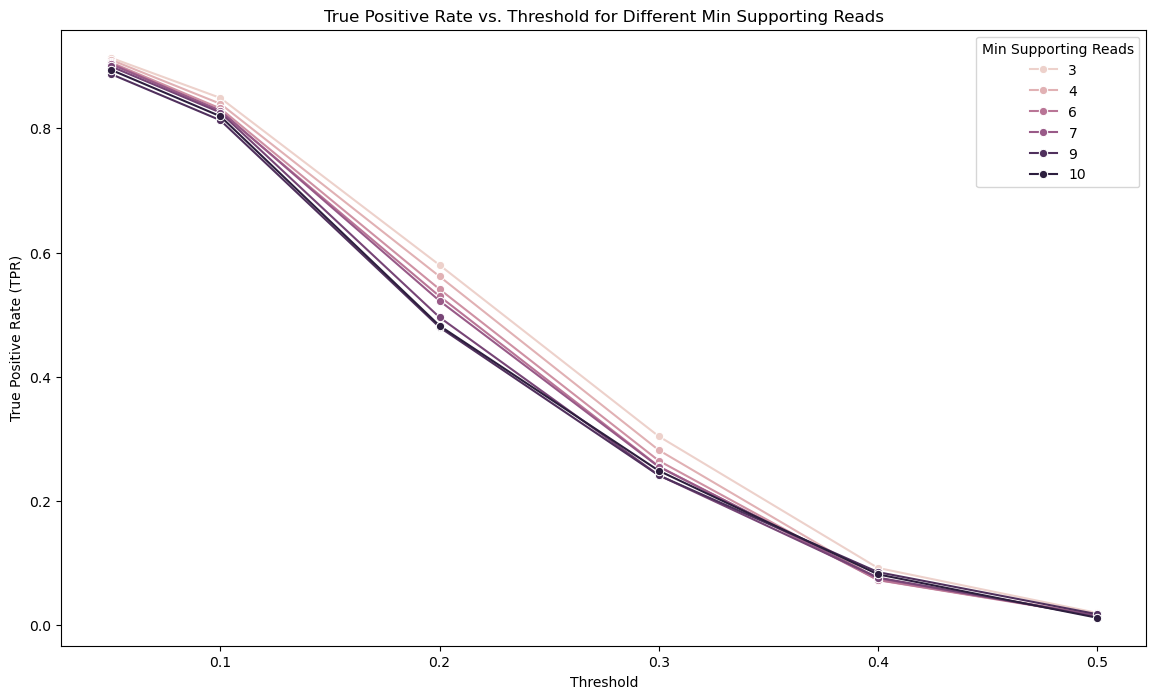

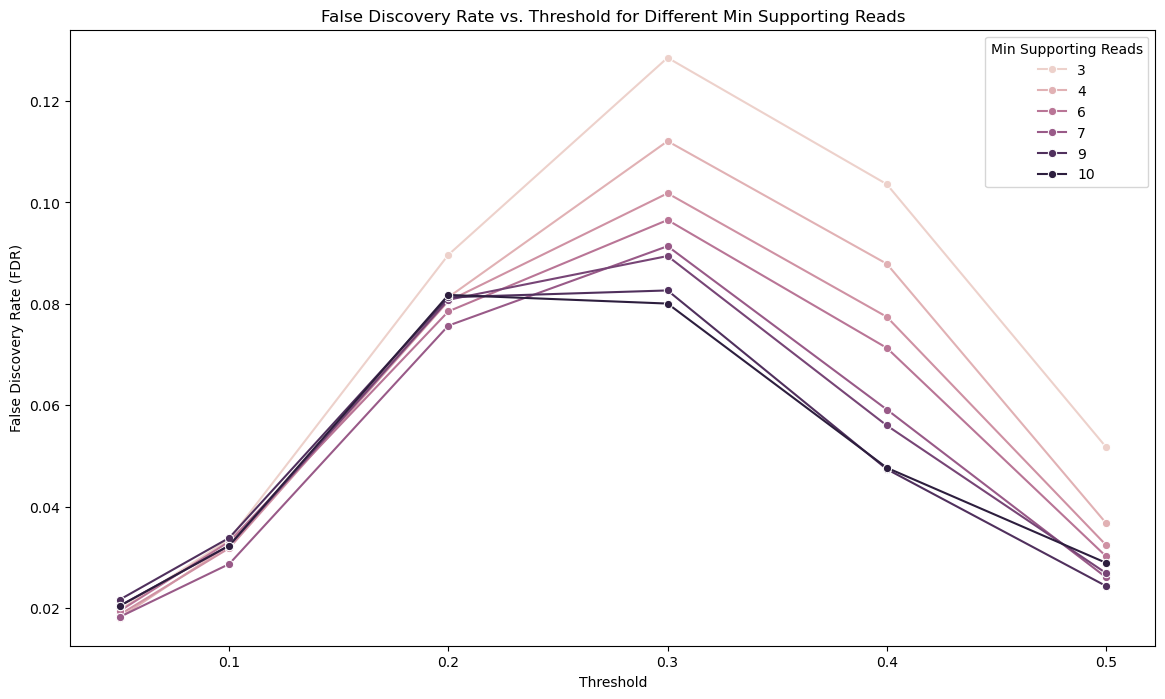

/tmp/ipykernel_382235/638170128.py:44: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title='Threshold')


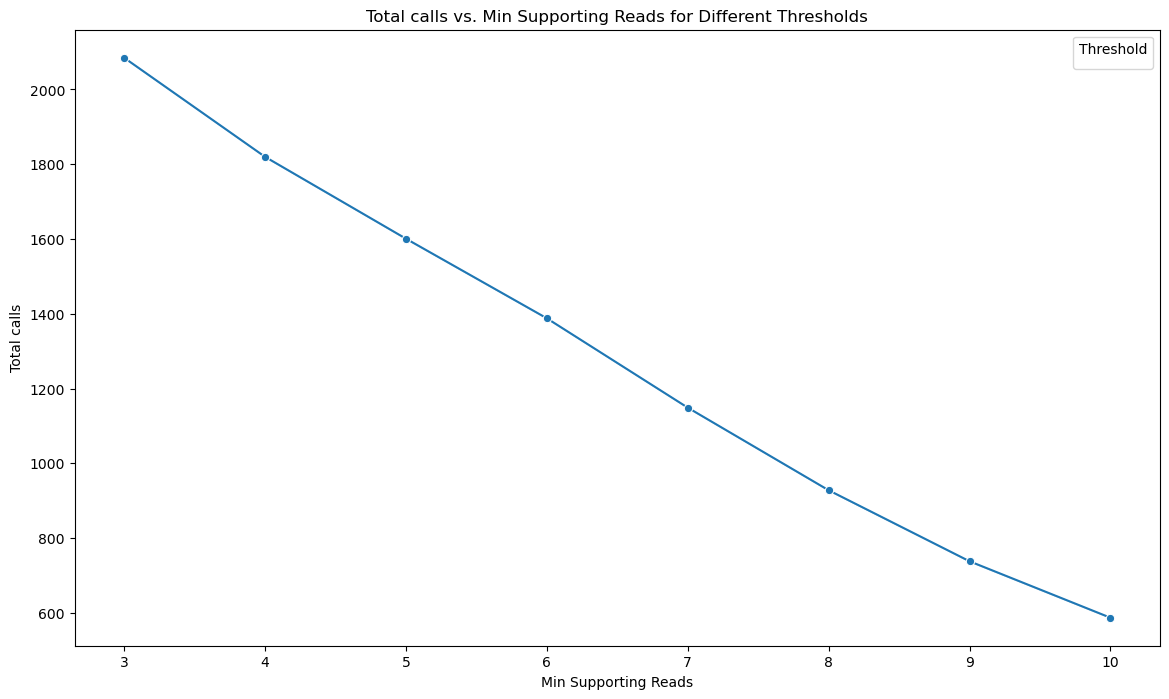

In [13]:
thresholds = [0.05, 0.1, 0.2, 0.3, 0.4, 0.5]
min_supporting_reads_list = [3, 4, 5, 6, 7, 8, 9, 10]
stdev_pos_thresholds = [0, 5, 10, 20, 30]

results = []
for threshold in thresholds:
    for min_supporting_reads in min_supporting_reads_list:
        result = benchmark_sv_methylation('./dataset/hapmap_benchmark/smoothing/ttest', all_final_checks_df, threshold=threshold, min_supporting_reads=min_supporting_reads)
        results.append((threshold, min_supporting_reads, result))

# Convert results to DataFrame for easier plotting
results_df = pd.DataFrame(results, columns=['Threshold', 'MinSupportingReads', 'Results'])
results_df[['BothAbove', 'HprcAboveHapmapNot', 'HapmapAboveHprcNot', 'BothBelow']] = pd.DataFrame(results_df['Results'].tolist(), index=results_df.index)

# Calculate True Positive Rate (TPR) and False Discovery Rate (FDR)
results_df['TPR'] = results_df['BothAbove'] / (results_df['BothAbove'] + results_df['HapmapAboveHprcNot'] + results_df['HprcAboveHapmapNot'] + results_df['BothBelow'])
results_df['FDR'] = results_df['HapmapAboveHprcNot'] / (results_df['BothAbove'] + results_df['HprcAboveHapmapNot'] + results_df['HapmapAboveHprcNot']+ results_df['BothBelow'])
results_df['Total'] = results_df['BothAbove'] + results_df['HprcAboveHapmapNot'] + results_df['HapmapAboveHprcNot']+ results_df['BothBelow']

# Plotting TPR
plt.figure(figsize=(14, 8))
sns.lineplot(data=results_df, x='Threshold', y='TPR', hue='MinSupportingReads', marker='o')
plt.xlabel('Threshold')
plt.ylabel('True Positive Rate (TPR)')
plt.title('True Positive Rate vs. Threshold for Different Min Supporting Reads')
plt.legend(title='Min Supporting Reads')
plt.show()

# Plotting FDR
plt.figure(figsize=(14, 8))
sns.lineplot(data=results_df, x='Threshold', y='FDR', hue='MinSupportingReads', marker='o')
plt.xlabel('Threshold')
plt.ylabel('False Discovery Rate (FDR)')
plt.title('False Discovery Rate vs. Threshold for Different Min Supporting Reads')
plt.legend(title='Min Supporting Reads')
plt.show()

# Plotting Total calls
plt.figure(figsize=(14, 8))
sns.lineplot(data=results_df, x='MinSupportingReads', y='Total', marker='o')
plt.xlabel('Min Supporting Reads')
plt.ylabel('Total calls')
plt.title('Total calls vs. Min Supporting Reads for Different Thresholds')
plt.legend(title='Threshold')
plt.show()



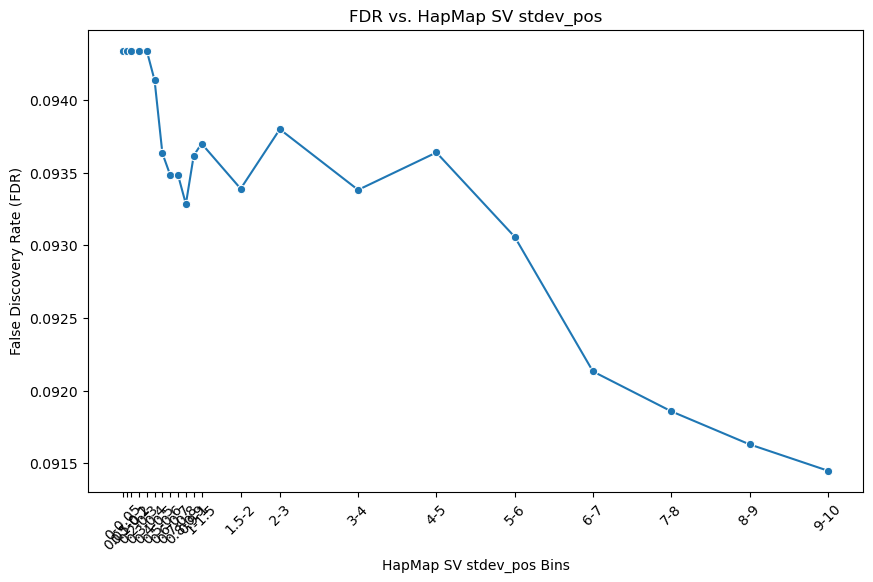

,Threshold,MinSupportingReads,Results,BothAbove,HprcAboveHapmapNot,HapmapAboveHprcNot,BothBelow,TPR,FDR,Total
0,0.00,10,"(1071, 502, 175, 107)",1071,502,175,107,0.577358,0.094340,1855
1,0.05,10,"(1071, 502, 175, 107)",1071,502,175,107,0.577358,0.094340,1855
2,0.10,10,"(1071, 502, 175, 107)",1071,502,175,107,0.577358,0.094340,1855
3,0.20,10,"(1071, 502, 175, 107)",1071,502,175,107,0.577358,0.094340,1855
4,0.30,10,"(1071, 502, 175, 107)",1071,502,175,107,0.577358,0.094340,1855
5,0.40,10,"(1072, 505, 175, 107)",1072,505,175,107,0.576654,0.094137,1859
6,0.50,10,"(1078, 508, 175, 108)",1078,508,175,108,0.576779,0.093633,1869
7,0.60,10,"(1081, 508, 175, 108)",1081,508,175,108,0.577457,0.093483,1872
8,0.70,10,"(1081, 508, 175, 108)",1081,508,175,108,0.577457,0.093483,1872
9,0.80,10,"(1085, 508, 175, 108)",1085,508,175,108,0.578358,0.093284,1876


In [56]:
# Define bins for stdev_pos_hapmap
bins = [0, 0.05, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1, 1.5, 2, 3, 4, 5, 6, 7, 8, 9, 10]
labels = [f'{bins[i]}-{bins[i+1]}' for i in range(len(bins)-1)]

# Create a new column in the DataFrame for the binned stdev_pos_hapmap
results = []
for threshold in bins[:-1]:  # Use bins[:-1] to match the number of labels
    result = benchmark_sv_methylation('./dataset/hapmap_benchmark/smoothing/ttest', all_final_checks_df, threshold=0.2, min_supporting_reads=3, max_stdev_pos=threshold)
    results.append((threshold, min_supporting_reads, result))

# Convert results to DataFrame for easier plotting
results_df = pd.DataFrame(results, columns=['Threshold', 'MinSupportingReads', 'Results'])
results_df[['BothAbove', 'HprcAboveHapmapNot', 'HapmapAboveHprcNot', 'BothBelow']] = pd.DataFrame(results_df['Results'].tolist(), index=results_df.index)

# Filter results_df to only include rows where Threshold is within the specified intervals
results_df = results_df[results_df['Threshold'].isin(bins[:-1])]

# Calculate True Positive Rate (TPR) and False Discovery Rate (FDR)
results_df['TPR'] = results_df['BothAbove'] / (results_df['BothAbove'] + results_df['HapmapAboveHprcNot'] + results_df['HprcAboveHapmapNot'] + results_df['BothBelow'])
results_df['FDR'] = results_df['HapmapAboveHprcNot'] / (results_df['BothAbove'] + results_df['HprcAboveHapmapNot'] + results_df['HapmapAboveHprcNot']+ results_df['BothBelow'])
results_df['Total'] = results_df['BothAbove'] + results_df['HprcAboveHapmapNot'] + results_df['HapmapAboveHprcNot']+ results_df['BothBelow']

# Plot the FDR against the binned stdev_pos_hapmap
plt.figure(figsize=(10, 6))
sns.lineplot(x='Threshold', y='FDR', data=results_df, marker='o')
plt.xticks(ticks=bins[:-1], labels=labels, rotation=45)  # Use bins[:-1] to match the number of labels
plt.xlabel('HapMap SV stdev_pos Bins')
plt.ylabel('False Discovery Rate (FDR)')
plt.title('FDR vs. HapMap SV stdev_pos')
plt.show()

results_df

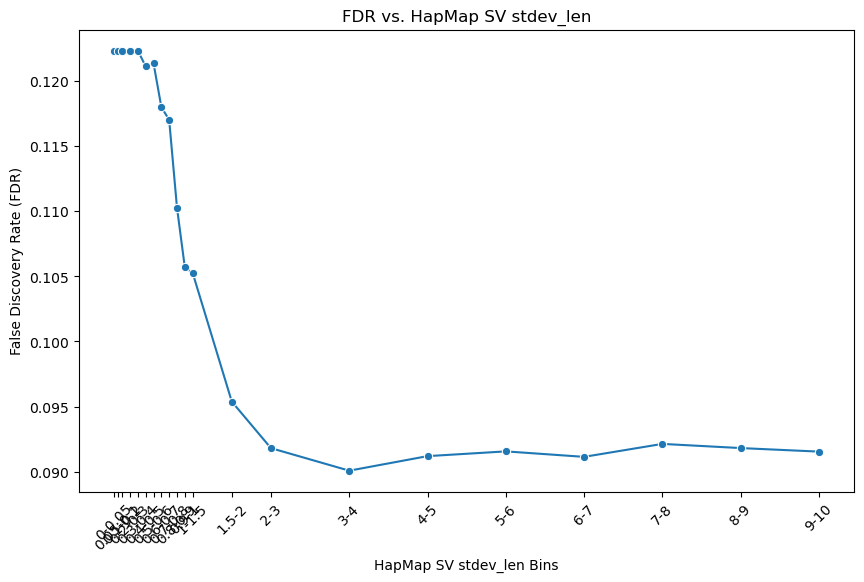

In [57]:
# Define bins for stdev_len_hapmap
bins = [0, 0.05, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1, 1.5, 2, 3, 4, 5, 6, 7, 8, 9, 10]
labels = [f'{bins[i]}-{bins[i+1]}' for i in range(len(bins)-1)]

# Create a new column in the DataFrame for the binned stdev_len_hapmap
results = []
for threshold in bins[:-1]:  # Use bins[:-1] to match the number of labels
    result = benchmark_sv_methylation('./dataset/hapmap_benchmark/smoothing/ttest', all_final_checks_df, threshold=0.2, min_supporting_reads=3, max_stdev_len=threshold)
    results.append((threshold, min_supporting_reads, result))

# Convert results to DataFrame for easier plotting
results_df = pd.DataFrame(results, columns=['Threshold', 'MinSupportingReads', 'Results'])
results_df[['BothAbove', 'HprcAboveHapmapNot', 'HapmapAboveHprcNot', 'BothBelow']] = pd.DataFrame(results_df['Results'].tolist(), index=results_df.index)

# Filter results_df to only include rows where Threshold is within the specified intervals
results_df = results_df[results_df['Threshold'].isin(bins[:-1])]

# Calculate True Positive Rate (TPR) and False Discovery Rate (FDR)
results_df['TPR'] = results_df['BothAbove'] / (results_df['BothAbove'] + results_df['HapmapAboveHprcNot'] + results_df['HprcAboveHapmapNot'] + results_df['BothBelow'])
results_df['FDR'] = results_df['HapmapAboveHprcNot'] / (results_df['BothAbove'] + results_df['HprcAboveHapmapNot'] + results_df['HapmapAboveHprcNot']+ results_df['BothBelow'])
results_df['Total'] = results_df['BothAbove'] + results_df['HprcAboveHapmapNot'] + results_df['HapmapAboveHprcNot']+ results_df['BothBelow']

# Plot the FDR against the binned stdev_len_hapmap
plt.figure(figsize=(10, 6))
sns.lineplot(x='Threshold', y='FDR', data=results_df, marker='o')
plt.xticks(ticks=bins[:-1], labels=labels, rotation=45)  # Use bins[:-1] to match the number of labels
plt.xlabel('HapMap SV stdev_len Bins')
plt.ylabel('False Discovery Rate (FDR)')
plt.title('FDR vs. HapMap SV stdev_len')
plt.show()


In [58]:
results_df

,Threshold,MinSupportingReads,Results,BothAbove,HprcAboveHapmapNot,HapmapAboveHprcNot,BothBelow,TPR,FDR,Total
0,0.00,10,"(426, 150, 86, 41)",426,150,86,41,0.605974,0.122333,703
1,0.05,10,"(426, 150, 86, 41)",426,150,86,41,0.605974,0.122333,703
2,0.10,10,"(426, 150, 86, 41)",426,150,86,41,0.605974,0.122333,703
3,0.20,10,"(426, 150, 86, 41)",426,150,86,41,0.605974,0.122333,703
4,0.30,10,"(426, 150, 86, 41)",426,150,86,41,0.605974,0.122333,703
5,0.40,10,"(429, 154, 86, 41)",429,154,86,41,0.604225,0.121127,710
6,0.50,10,"(459, 166, 92, 41)",459,166,92,41,0.605541,0.121372,758
7,0.60,10,"(498, 183, 97, 44)",498,183,97,44,0.605839,0.118005,822
8,0.70,10,"(504, 184, 97, 44)",504,184,97,44,0.607961,0.117008,829
9,0.80,10,"(557, 210, 101, 48)",557,210,101,48,0.608079,0.110262,916


In [17]:
print(benchmark_sv_methylation('./dataset/hapmap_benchmark/smoothing/fisher', all_final_checks_df, threshold=0.05, min_supporting_reads=5),
benchmark_sv_methylation('./dataset/hapmap_benchmark/smoothing/ttest', all_final_checks_df, threshold=0.05, min_supporting_reads=5),
benchmark_sv_methylation('./dataset/hapmap_benchmark/no_smoothing/fisher', all_final_checks_df, threshold=0.05, min_supporting_reads=5),
benchmark_sv_methylation('./dataset/hapmap_benchmark/no_smoothing/ttest', all_final_checks_df, threshold=0.05, min_supporting_reads=5))

(972, 510, 42, 77) (1451, 110, 30, 10) (914, 554, 46, 87) (1453, 109, 32, 7)


In [ ]:
# ./sniffmeth -v ./dataset/hapmap_smaht_ont_mosaic.vcf.gz -b ../hapmap_data/hapmap_smaht_ont.bam -r ../../../references/GCA_000001405.15_GRCh38_no_alt_analysis_set.fa -s 10 -o ./dataset/hapmap_benchmark/smoothing/ttest/hapmap_all -m 3 -t 20
# ./sniffmeth -v ./dataset/hapmap_smaht_ont_mosaic.vcf.gz -b ../hapmap_data/hapmap_smaht_ont.bam -r ../../../references/GCA_000001405.15_GRCh38_no_alt_analysis_set.fa --o ./dataset/hapmap_benchmark/no_smoothing/ttest/hapmap_all -m 3 -t 20

/bin/bash: sniffmeth: command not found
/bin/bash: sniffmeth: command not found


In [70]:
hapmap_all_sv_methylation_df = pd.read_csv("./dataset/hapmap_benchmark/smoothing/ttest/hapmap_all/sv_methylation_df.csv", index_col=0)

/tmp/ipykernel_382235/813666968.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  hapmap_all_sv_methylation_df_filtered['supporting_reads_count'] = hapmap_all_sv_methylation_df_filtered['supporting_reads'].apply(count_elements_in_tuple_string)


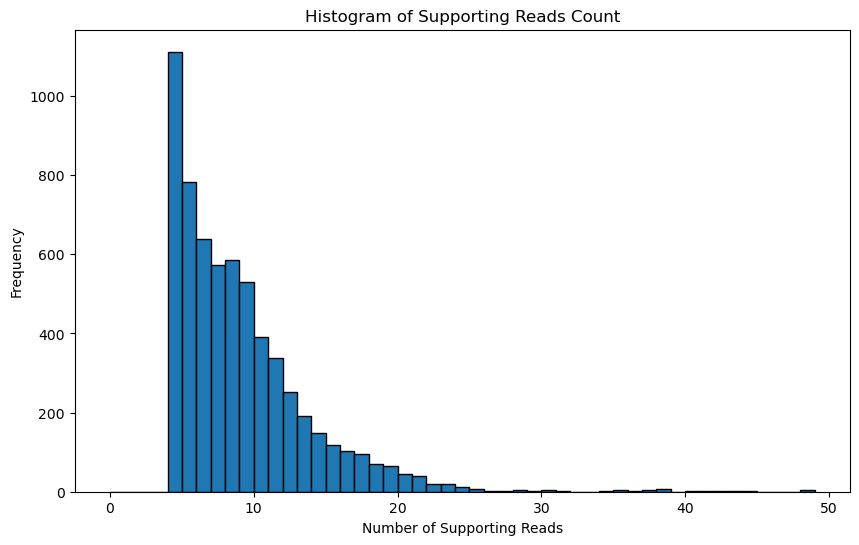

In [73]:
hapmap_all_sv_methylation_df_filtered = hapmap_all_sv_methylation_df[(hapmap_all_sv_methylation_df["cpg_diff_percentage"] > 0.2) & (hapmap_all_sv_methylation_df["supporting_reads"].apply(count_elements_in_tuple_string) > 1) & (hapmap_all_sv_methylation_df["supporting_reads"].apply(count_elements_in_tuple_string) < 50) & (hapmap_all_sv_methylation_df["stdev_pos"] < 5)]
plt.figure(figsize=(10, 6))
hapmap_all_sv_methylation_df_filtered['supporting_reads_count'] = hapmap_all_sv_methylation_df_filtered['supporting_reads'].apply(count_elements_in_tuple_string)
hapmap_all_sv_methylation_df_filtered['supporting_reads_count'].plot(kind='hist', edgecolor='black', bins=range(0, 50, 1))
plt.xlabel('Number of Supporting Reads')
plt.ylabel('Frequency')
plt.title('Histogram of Supporting Reads Count')
plt.show()

/tmp/ipykernel_382235/1909017266.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sample_df['supporting_reads_count'] = sample_df['supporting_reads_hapmap'].apply(count_elements_in_tuple_string)


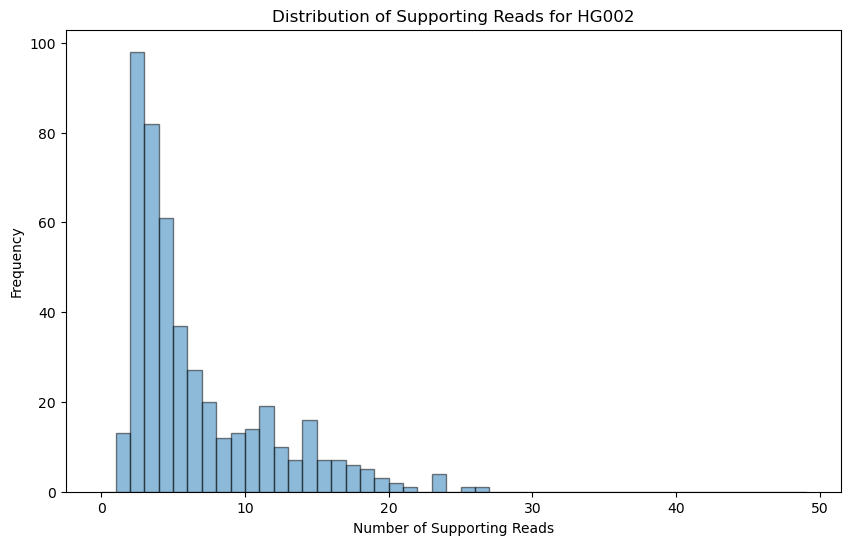

/tmp/ipykernel_382235/1909017266.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sample_df['supporting_reads_count'] = sample_df['supporting_reads_hapmap'].apply(count_elements_in_tuple_string)


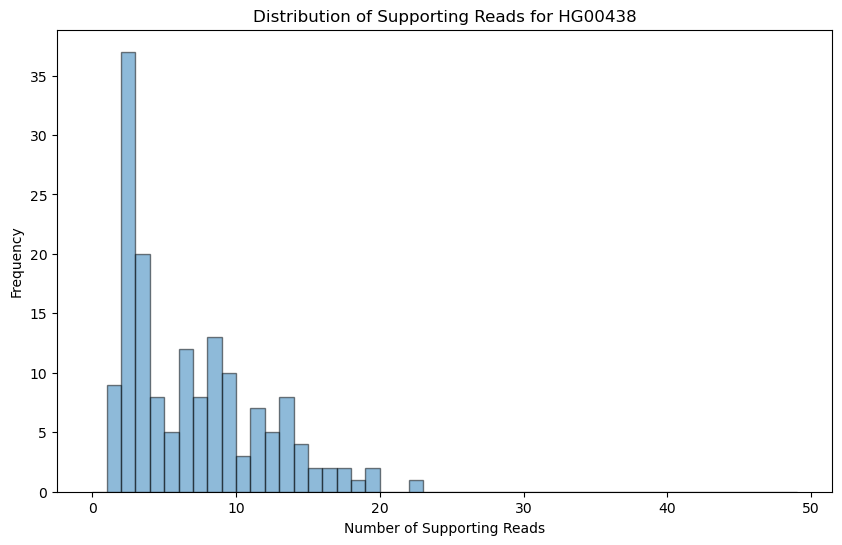

/tmp/ipykernel_382235/1909017266.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sample_df['supporting_reads_count'] = sample_df['supporting_reads_hapmap'].apply(count_elements_in_tuple_string)


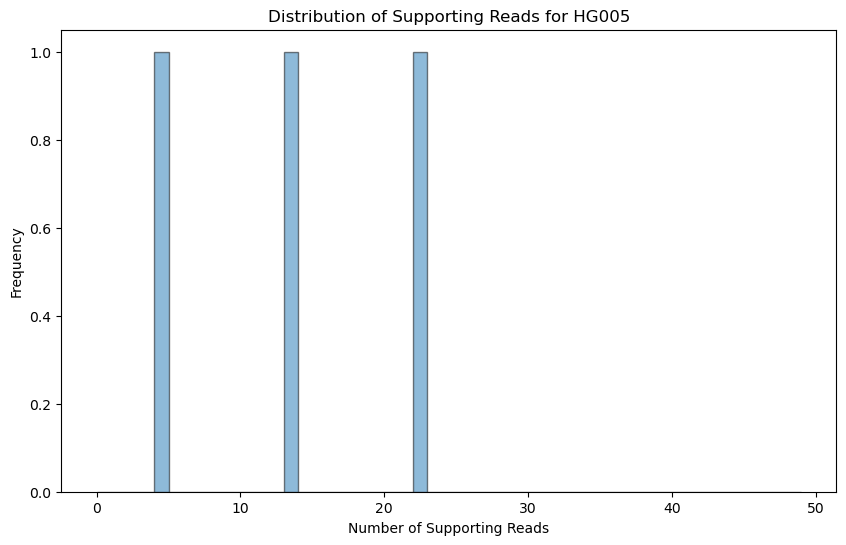

/tmp/ipykernel_382235/1909017266.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sample_df['supporting_reads_count'] = sample_df['supporting_reads_hapmap'].apply(count_elements_in_tuple_string)


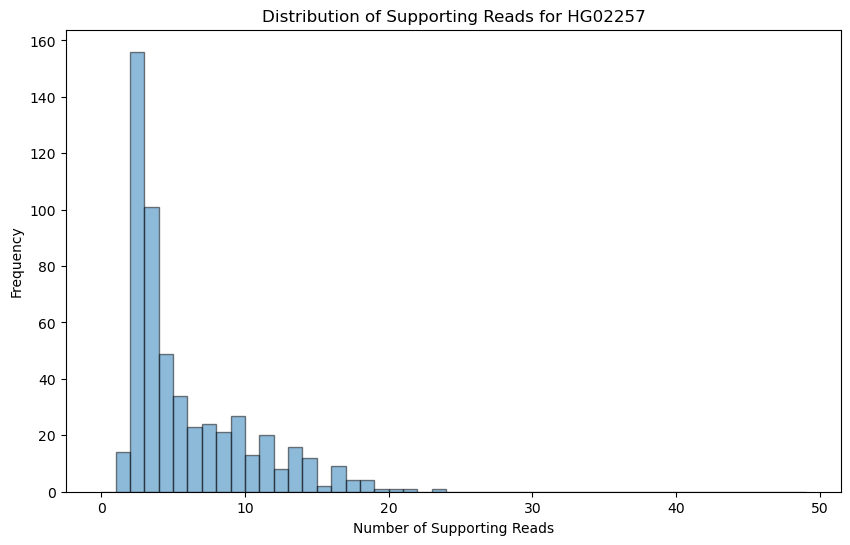

/tmp/ipykernel_382235/1909017266.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sample_df['supporting_reads_count'] = sample_df['supporting_reads_hapmap'].apply(count_elements_in_tuple_string)


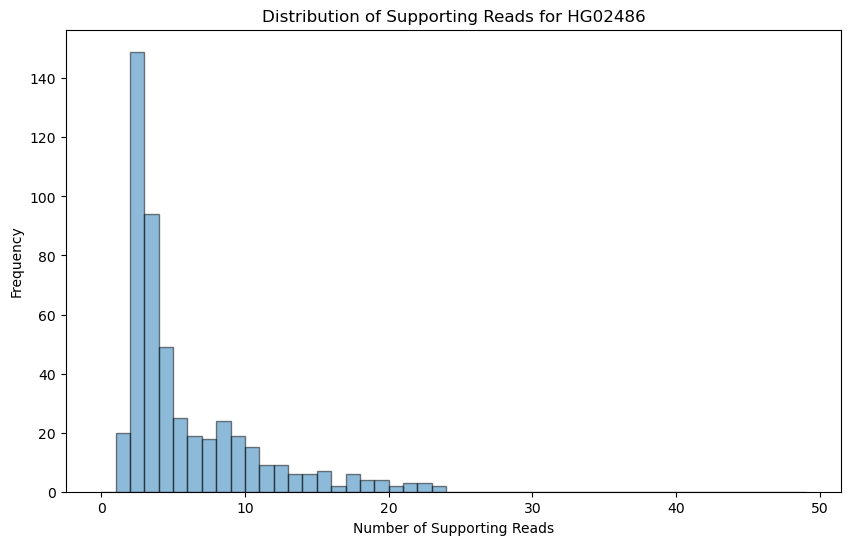

/tmp/ipykernel_382235/1909017266.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sample_df['supporting_reads_count'] = sample_df['supporting_reads_hapmap'].apply(count_elements_in_tuple_string)


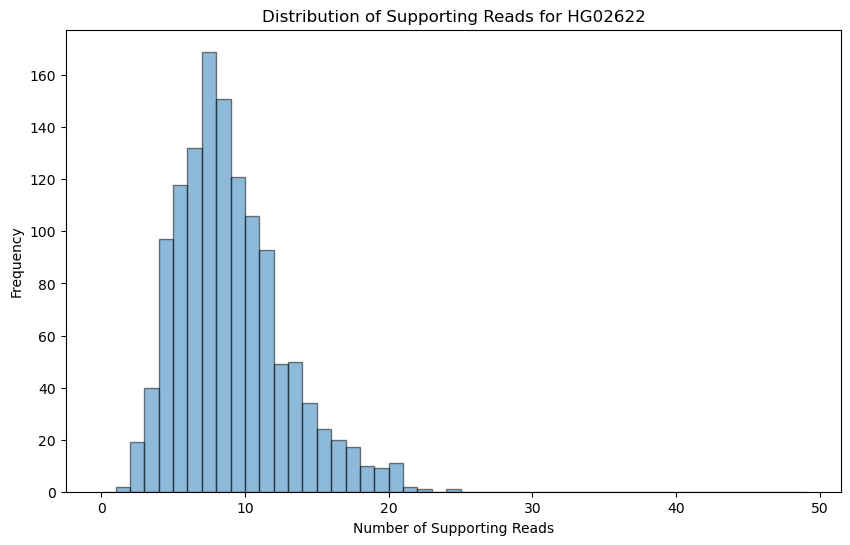

In [78]:
for sample in hprc_sample_list:
    plt.figure(figsize=(10, 6))
    sample_df = all_final_checks_df[all_final_checks_df['sample_name_asm_hprc'] == sample]
    sample_df['supporting_reads_count'] = sample_df['supporting_reads_hapmap'].apply(count_elements_in_tuple_string)
    sample_df['supporting_reads_count'].plot(kind='hist', alpha=0.5, bins=range(0, 50, 1), edgecolor='black')
    plt.xlabel('Number of Supporting Reads')
    plt.ylabel('Frequency')
    plt.title(f'Distribution of Supporting Reads for {sample}')
    plt.show()


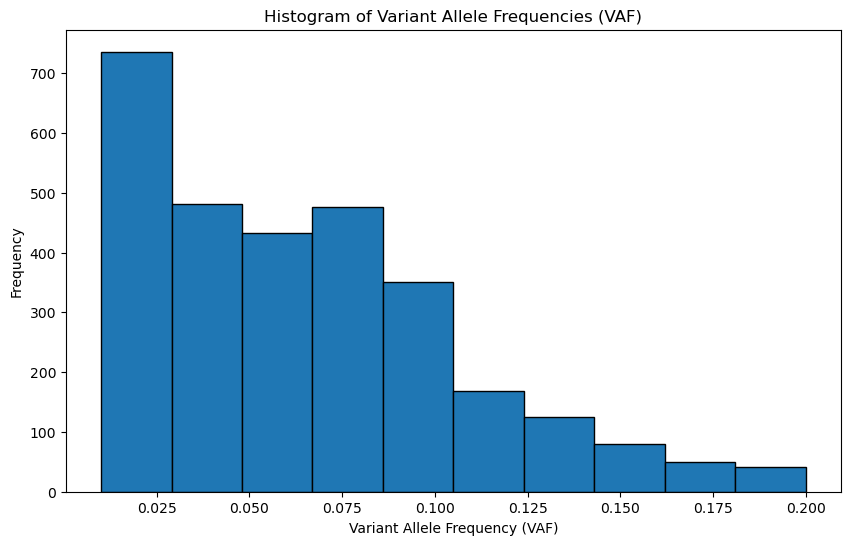

In [16]:
#
def read_vcf_and_calculate_vaf(vcf_file):
    vcf = pysam.VariantFile(vcf_file)
    vaf_dict = {}
    for record in vcf:
        sv_id = record.id
        vaf_dict.update({sv_id: record.info.get('AF')})
    return vaf_dict

# Example usage:
vaf_dict = read_vcf_and_calculate_vaf("./dataset/hapmap_benchmark/benchmark_sv_vcf/hapmap_benchmark_sv.vcf")
# Draw a histogram of all the VAFs
plt.figure(figsize=(10, 6))
plt.hist(vaf_dict.values(), bins=10, edgecolor='black')
plt.xlabel('Variant Allele Frequency (VAF)')
plt.ylabel('Frequency')
plt.title('Histogram of Variant Allele Frequencies (VAF)')
plt.show()